<a href="https://www.kaggle.com/code/riteshkumarweb/precision-recall-f1score-multi-class?scriptVersionId=314011887" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [130]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/organizations/uciml/red-wine-quality-cortez-et-al-2009/winequality-red.csv


In [131]:
# Confusion Matrix in Multi-Class Classification:
# In multi-class classification, the confusion matrix becomes an n x n table
# where n = number of classes.

# Example:
# Classes = A, B, C

#                Predicted
#              A    B    C
# Actual A    40    5    5
# Actual B     4   35   11
# Actual C     3    7   40

# Row = Actual Class
# Column = Predicted Class

# Diagonal values = Correct Predictions
# A predicted as A = 40
# B predicted as B = 35
# C predicted as C = 40

# Off-diagonal values = Wrong Predictions
# Example:
# B predicted as C = 11
# C predicted as B = 7

# Total Correct Predictions:
# 40 + 35 + 40 = 115

# Accuracy Formula:
# Accuracy = Sum of diagonal values / Total number of predictions

# Accuracy = 115 / 150 = 76.7%

# Why it is useful:
# It helps us understand:
# Which class is predicted correctly
# Which class is getting confused with another class

# Example:
# If many B are predicted as C,
# then the model is confused between B and C.

In [132]:
# Precision:
# Precision tells us:
# Out of all the times the model predicted Positive (YES),
# how many were actually correct?

# Simple Meaning:
# "When the model says YES, how often is it right?"

# Formula:
# Precision = TP / (TP + FP)

# Where:
# TP = True Positive
# FP = False Positive


# Precision in Binary Classification (2 Classes):
# Example:
# Spam Detection

# Positive = Spam
# Negative = Not Spam

# Suppose:
# Model predicted 20 emails as Spam

# Out of them:
# 15 were actually Spam -> TP
# 5 were normal emails wrongly marked as Spam -> FP

# Precision = 15 / (15 + 5)
# Precision = 15 / 20
# Precision = 75%

# Meaning:
# When the model says "Spam",
# it is correct 75% of the time.


# Precision in Multi-Class Classification:
# In multi-class classification,
# Precision is calculated separately for EACH class.

# Example:
# Classes = A, B, C

#                Predicted
#              A    B    C
# Actual A    40    5    5
# Actual B     4   35   11
# Actual C     3    7   40

# Precision for Class A:

# TP_A = 40
# (Actual A predicted as A)

# FP_A = 4 + 3 = 7
# (B and C wrongly predicted as A)

# Formula:
# Precision_A = TP_A / (TP_A + FP_A)

# Precision_A = 40 / (40 + 7)
# Precision_A = 40 / 47
# Precision_A = 85.1%

# Meaning:
# Out of all predictions made as Class A,
# how many were actually Class A?

# Same calculation is done for:
# Precision_B
# Precision_C

# Then we use:
# Macro Average
# Micro Average
# Weighted Average

# to get one final overall Precision score.

In [133]:
# Recall:
# Recall tells us:
# Out of all the actual Positive (YES) cases,
# how many did the model correctly identify?

# Simple Meaning:
# "Did the model catch most of the real YES cases?"

# Formula:
# Recall = TP / (TP + FN)

# Where:
# TP = True Positive
# FN = False Negative


# Recall in Binary Classification (2 Classes):
# Example:
# Disease Detection

# Positive = Disease
# Negative = No Disease

# Suppose:
# 100 people actually have the disease

# Model correctly identifies:
# 80 people as sick -> TP

# But misses:
# 20 sick people and predicts them as healthy -> FN

# Recall = 80 / (80 + 20)
# Recall = 80 / 100
# Recall = 80%

# Meaning:
# Out of all sick people,
# the model found 80% of them.


# Recall in Multi-Class Classification:
# Recall is calculated separately for EACH class.

# Example:
# Classes = A, B, C

#                Predicted
#              A    B    C
# Actual A    40    5    5
# Actual B     4   35   11
# Actual C     3    7   40

# Recall for Class A:

# TP_A = 40
# (Actual A predicted as A)

# FN_A = 5 + 5 = 10
# (Actual A wrongly predicted as B and C)

# Formula:
# Recall_A = TP_A / (TP_A + FN_A)

# Recall_A = 40 / (40 + 10)
# Recall_A = 40 / 50
# Recall_A = 80%

# Meaning:
# Out of all actual Class A,
# how many were correctly predicted as A?

# Same calculation is done for:
# Recall_B
# Recall_C

# Then we use:
# Macro Average
# Micro Average
# Weighted Average

# to get one final overall Recall score.

In [134]:
# F1 Score:
# F1 Score is used when we want both
# Precision and Recall together.

# It gives one single score
# that balances both Precision and Recall.

# Simple Meaning:
# "Is the model good at both catching positives
# and avoiding wrong positive predictions?"

# Formula:
# F1 Score =
# 2 * (Precision * Recall) / (Precision + Recall)


# F1 Score in Binary Classification:
# Example:

# Precision = 80%
# Recall = 60%

# F1 Score =
# 2 * (0.8 * 0.6) / (0.8 + 0.6)

# F1 Score =
# 2 * 0.48 / 1.4

# F1 Score = 0.69 = 69%

# Meaning:
# It gives a balanced score of Precision and Recall.


# F1 Score in Multi-Class Classification:
# F1 Score is also calculated separately
# for EACH class.

# Example for Class A:

# Precision_A = 85.1%
# Recall_A = 80%

# Formula:
# F1_A =
# 2 * (Precision_A * Recall_A)
# / (Precision_A + Recall_A)

# F1_A ≈ 82.5%

# Meaning:
# It tells how balanced Precision and Recall are
# for Class A.

# Same calculation is done for:
# F1_B
# F1_C

# Then we use:
# Macro Average
# Micro Average
# Weighted Average

# to get one final overall F1 Score.

In [135]:
# Macro Average, Micro Average, Weighted Average:
# In multi-class classification, we calculate Precision,
# Recall, and F1-score separately for each class.

# Example:
# Precision_A = 90%
# Precision_B = 60%
# Precision_C = 30%

# Now the problem is:
# We have 3 different Precision values,
# but we need ONE final overall Precision score.

# That is why we use:
# Macro Average
# Micro Average
# Weighted Average


# 1. Macro Average:
# Definition:
# It gives equal importance to every class,
# no matter how many samples each class has.

# Formula:
# Macro Precision = (Precision_A + Precision_B + Precision_C) / Number of Classes

# Example:
# Macro Precision = (90 + 60 + 30) / 3
# Macro Precision = 180 / 3
# Macro Precision = 60%

# Meaning:
# Even if Class C has very few samples,
# it gets equal importance like Class A.

# Use when:
# All classes are equally important.


# 2. Weighted Average:
# Definition:
# It gives more importance to classes
# that have more samples.

# Example:
# Class A = 100 students
# Class B = 20 students
# Class C = 10 students

# Since Class A is much bigger,
# it should affect the final score more.

# Formula:
# Weighted Precision =
# (Precision_A * Support_A +
#  Precision_B * Support_B +
#  Precision_C * Support_C)
# / Total Samples

# Meaning:
# Big classes matter more.

# Use when:
# Dataset is imbalanced.


# 3. Micro Average:
# Definition:
# Instead of averaging class-wise scores,
# it combines total TP, FP, FN first,
# then calculates Precision, Recall, F1.

# Formula:
# Micro Precision =
# Total TP / (Total TP + Total FP)

# Meaning:
# It checks overall system performance.

# Use when:
# You care about total prediction performance
# more than individual class fairness.


# Easy Memory Trick:

# Macro   = Equal importance to all classes
# Weighted = Importance based on class size
# Micro   = Overall total performance

In [136]:
df = pd.read_csv('/kaggle/input/datasets/organizations/uciml/red-wine-quality-cortez-et-al-2009/winequality-red.csv')

In [137]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [138]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [139]:
df['quality'].value_counts()

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64

In [140]:
df.corr()['quality'].sort_values()

volatile acidity       -0.390558
total sulfur dioxide   -0.185100
density                -0.174919
chlorides              -0.128907
pH                     -0.057731
free sulfur dioxide    -0.050656
residual sugar          0.013732
fixed acidity           0.124052
citric acid             0.226373
sulphates               0.251397
alcohol                 0.476166
quality                 1.000000
Name: quality, dtype: float64

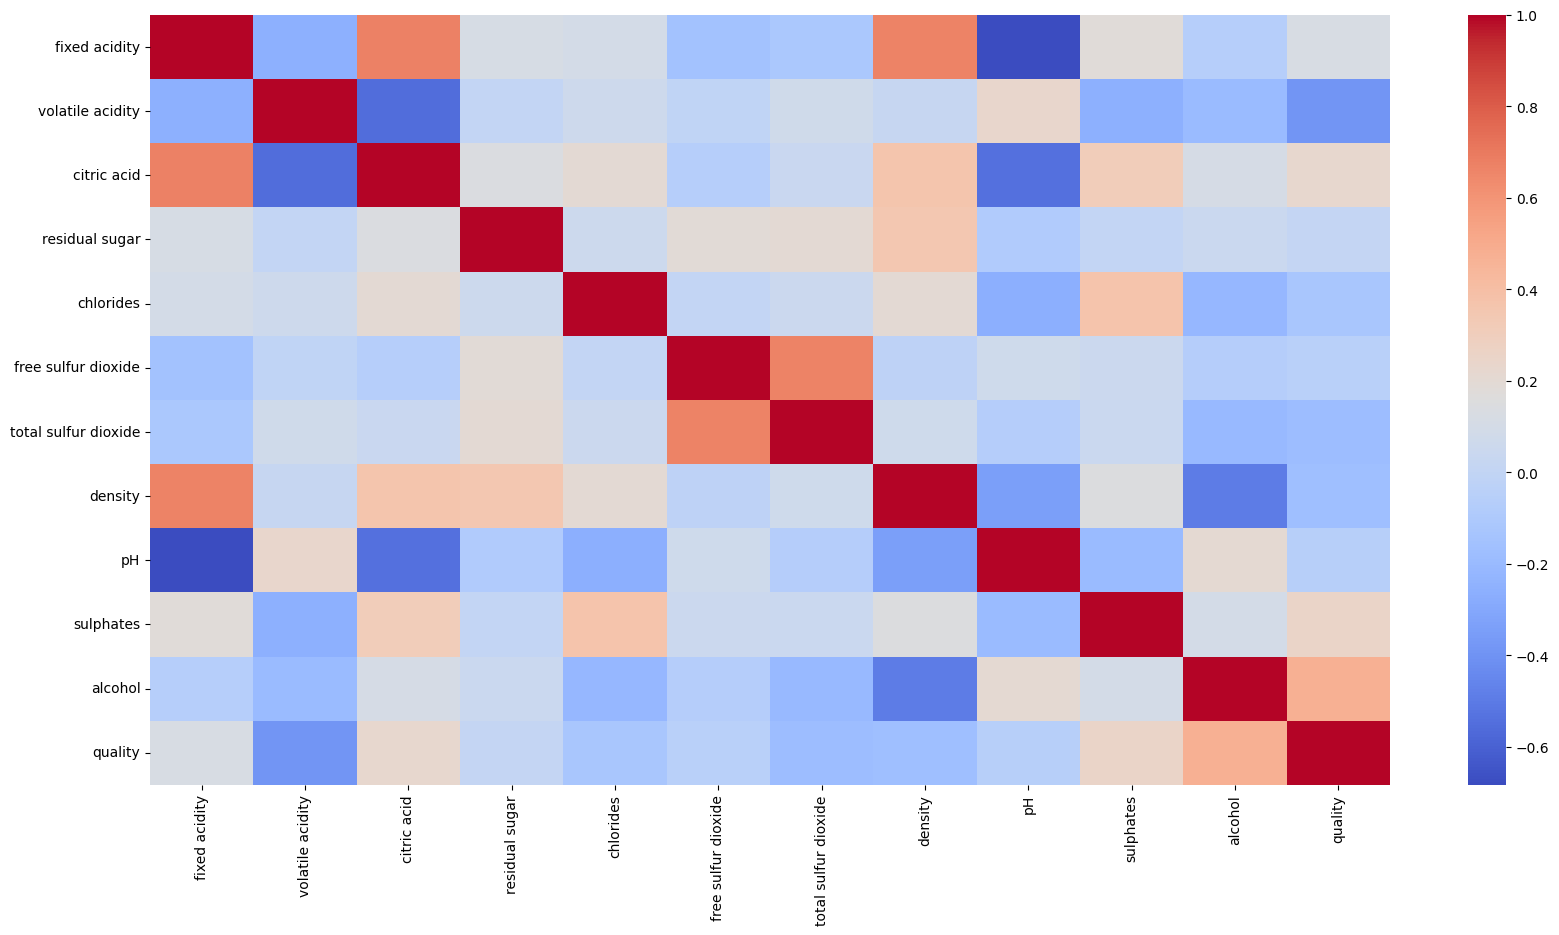

In [141]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.show()

<Axes: xlabel='quality', ylabel='alcohol'>

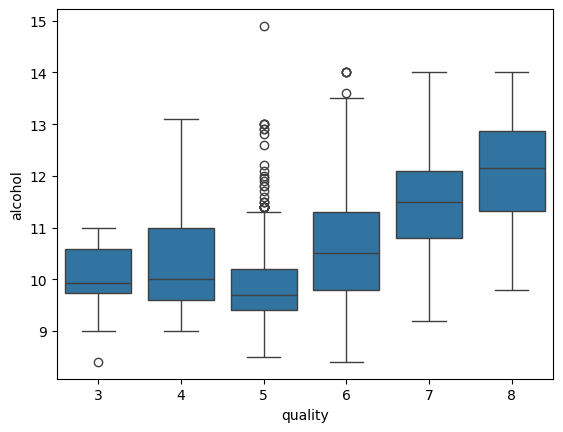

In [142]:
import seaborn as sns 
sns.boxplot(x='quality', y='alcohol', data=df)

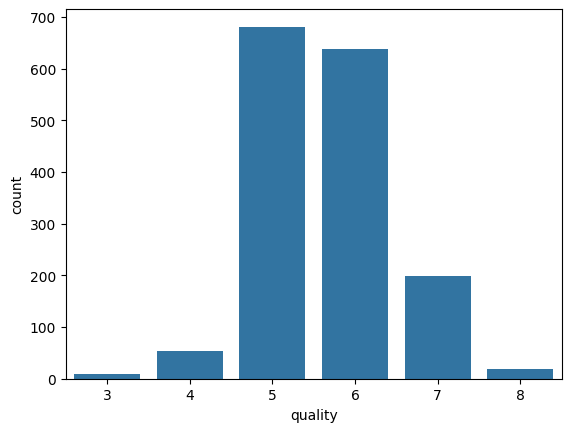

In [143]:
sns.countplot(x="quality", data=df)
plt.show()

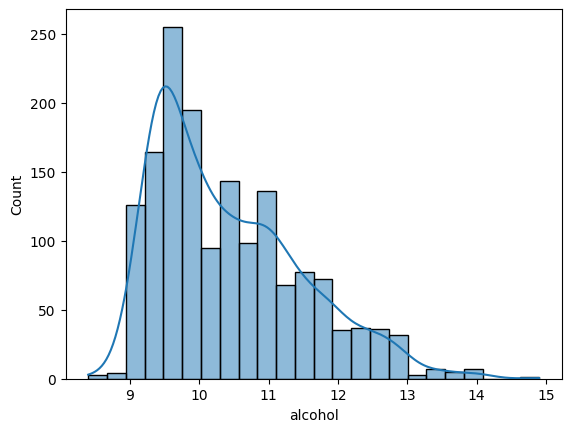

In [144]:
sns.histplot(df["alcohol"], kde=True)
plt.show()

In [145]:
df.sample(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
661,7.5,0.420,0.31,1.60,0.080,15.0,42.0,0.99780,3.31,0.64,9.0,5
1482,7.2,0.580,0.54,2.10,0.114,3.0,9.0,0.99719,3.33,0.57,10.3,4
690,7.4,1.185,0.00,4.25,0.097,5.0,14.0,0.99660,3.63,0.54,10.7,3
947,8.3,0.280,0.48,2.10,0.093,6.0,12.0,0.99408,3.26,0.62,12.4,7
356,11.5,0.410,0.52,3.00,0.080,29.0,55.0,1.00010,3.26,0.88,11.0,5


In [146]:
X = df.iloc[:,0:11]
X

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4
...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2


In [147]:
y = df.iloc[:,-1]
y

0       5
1       5
2       5
3       6
4       5
       ..
1594    5
1595    6
1596    6
1597    5
1598    6
Name: quality, Length: 1599, dtype: int64

In [148]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
# Import the class
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier


# Step 1: Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Step 2: Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [149]:
model1 = LogisticRegression()
model2 = DecisionTreeClassifier()

In [150]:
model1.fit(X_train,y_train)


LogisticRegression()

In [151]:
model2.fit(X_train,y_train)

DecisionTreeClassifier()

In [152]:
y_predict1 = model1.predict(X_test)

In [153]:
y_predict2 = model2.predict(X_test)

In [154]:
from sklearn.metrics import accuracy_score,confusion_matrix,f1_score, precision_score, recall_score
# 📊 Confusion Matrix compares Actual values vs Predicted values

# It shows:
# ✅ Correct predictions
# ❌ Wrong predictions

# Diagonal values → Correct predictions
# Off-diagonal values → Wrong predictions (model confusion)

# It helps us understand where the model is making mistakes
# and why accuracy is high or low

print("For Logistic regression Model\n")
pd.DataFrame(confusion_matrix(y_test,y_predict1),columns=list(range(0,6)))

# columns=list(range(0,6))
# → Creates column names from 0 to 5
# This means there are 6 classes:
# Class 0, Class 1, Class 2, Class 3, Class 4, Class 5

# 🎯 Goal:
# To display the confusion matrix in a clean tabular form


For Logistic regression Model



,0,1,2,3,4,5
0,0,0,1,0,0,0
1,0,1,7,2,0,0
2,0,0,98,32,0,0
3,0,0,46,76,10,0
4,0,0,3,30,9,0
5,0,0,0,1,4,0


In [155]:
from sklearn.metrics import accuracy_score,confusion_matrix,f1_score, precision_score, recall_score
# 📊 Confusion Matrix compares Actual values vs Predicted values

# It shows:
# ✅ Correct predictions
# ❌ Wrong predictions

# Diagonal values → Correct predictions
# Off-diagonal values → Wrong predictions (model confusion)

# It helps us understand where the model is making mistakes
# and why accuracy is high or low

print("For Decesion Tree regression Model\n")
pd.DataFrame(confusion_matrix(y_test,y_predict2),columns=list(range(0,6)))
# columns=list(range(0,6))
# → Creates column names from 0 to 5
# This means there are 6 classes:
# Class 0, Class 1, Class 2, Class 3, Class 4, Class 5

# 🎯 Goal:
# To display the confusion matrix in a clean tabular form


For Decesion Tree regression Model



,0,1,2,3,4,5
0,0,0,0,1,0,0
1,0,0,5,5,0,0
2,1,4,88,34,3,0
3,0,3,38,74,15,2
4,0,1,4,15,20,2
5,0,0,1,1,2,1


In [156]:
# 📊 Calculate Precision Score

# Precision tells:
# Out of all predicted positives,
# how many were actually correct

# Formula:
# Precision = TP / (TP + FP)

# average=None
# → Returns precision for EACH class separately

# zero_division=0
# → If precision cannot be calculated
# (for example, model never predicted that class),
# then return 0 instead of warning/error

# ⚠️ Default values if you do NOT give parameters:

# average = 'binary'
# → Used mainly for Binary Classification
# → Calculates precision only for positive class (usually class 1)

# zero_division = 'warn'
# → Shows warning and returns 0 if division problem happens

precision_score(y_test, y_predict1, average=None, zero_division=0)

array([0.        , 1.        , 0.63225806, 0.53900709, 0.39130435,
       0.        ])

In [157]:
# 📊 Recall Score

# Recall tells:
# Out of all actual positives,
# how many were correctly predicted

# Formula:
# Recall = TP / (TP + FN)

# average=None
# → Returns recall for EACH class separately

# zero_division=0
# → If recall cannot be calculated,
# return 0 instead of warning/error

# ⚠️ Default values if parameters are not given:

# average = 'binary'
# → Mainly for Binary Classification
# → Calculates recall for positive class (usually class 1)

# zero_division = 'warn'
# → Shows warning and returns 0 if division problem happens

recall_score(y_test, y_predict1, average=None)

array([0.        , 0.1       , 0.75384615, 0.57575758, 0.21428571,
       0.        ])

In [158]:
# 📊 F1 Score

# F1 Score is the balance between Precision and Recall

# Formula:
# F1 = 2 * (Precision * Recall) / (Precision + Recall)

# It is useful when both False Positive
# and False Negative are important

# average=None
# → Returns F1-score for EACH class separately

# zero_division=0
# → If F1 cannot be calculated,
# return 0 instead of warning/error

# ⚠️ Default values if parameters are not given:

# average = 'binary'
# → Mainly for Binary Classification
# → Calculates F1-score for positive class (usually class 1)

# zero_division = 'warn'
# → Shows warning and returns 0 if division problem happens

f1_score(y_test, y_predict1, average=None)

array([0.        , 0.18181818, 0.6877193 , 0.55677656, 0.27692308,
       0.        ])

In [159]:
# 📊 Calculate Precision Score using Macro Average
# average='macro'
# → Calculate precision for each class separately first
# → Then take the simple average of all classes

# ⚠️ Macro does NOT care about class imbalance
# Every class gets equal importance

# Example:
# Class 0 precision = 0.90
# Class 1 precision = 0.80
# Class 2 precision = 0.70

# Macro Precision:
# (0.90 + 0.80 + 0.70) / 3 = 0.80

# zero_division=0
# → If precision cannot be calculated,
# return 0 instead of warning/error

# Other important average parameters:

# average='weighted'
# → Like macro, but gives more importance
# to classes with more samples

# Useful when dataset is imbalanced

# average='micro'
# → Calculates global precision by counting
# total TP, FP across all classes first

# Useful when overall system performance matters

# average=None
# → Returns precision score for each class separately

precision_score(
    y_test,
    y_predict1,
    average='macro',
    zero_division=0
)  # Also have parameters: weighted, micro

0.4270949174234662

In [160]:
# 📊 Calculate Recall Score using Weighted Average

# Recall tells:
# Out of all actual positives,
# how many were correctly predicted

# Formula:
# Recall = TP / (TP + FN)

# average='weighted'
# → Calculate recall for each class separately first
# → Then take the weighted average based on class support (number of samples)

# ⚠️ Weighted gives more importance
# to classes with more data

# Useful when dataset is imbalanced

# Example:
# Class 0 → 100 samples
# Class 1 → 20 samples
# Class 2 → 10 samples

# Here Class 0 affects the final score more

# Other important average parameters:

# average='macro'
# → Simple average of recall of all classes
# → Every class gets equal importance

# average='micro'
# → Calculates global recall by counting
# total TP and FN across all classes first

# average=None
# → Returns recall score for each class separately

# ⚠️ Default if parameter is not given:

# average = 'binary'
# → Mainly for Binary Classification

recall_score(
    y_test,
    y_predict1,
    average='weighted'
)  # Also have parameters: Micro, Macro

0.575

In [161]:
# 📊 Calculate F1 Score using Micro Average

# y_test → Actual / True values
# y_predict1 → Predicted values by the model

# F1 Score is the balance between Precision and Recall

# Formula:
# F1 = 2 * (Precision * Recall) / (Precision + Recall)

# It is useful when both False Positive
# and False Negative are important

# average='micro'
# → First count total TP, FP, FN across all classes
# → Then calculate one overall F1-score

# ⚠️ Micro focuses on overall system performance
# instead of individual class performance

# Useful when total prediction performance matters most

# Other important average parameters:

# average='macro'
# → Calculate F1 for each class separately
# → Then take simple average
# → Every class gets equal importance

# average='weighted'
# → Like macro, but gives more importance
# to classes with more samples

# average=None
# → Returns F1-score for each class separately

# ⚠️ Default if parameter is not given:

# average = 'binary'
# → Mainly for Binary Classification

f1_score(
    y_test,
    y_predict1,
    average='micro'
)  # Also have parameters: weighted, macro


0.575

In [162]:
# 📦 Import classification_report from sklearn.metrics
# This function gives a full summary of classification performance

from sklearn.metrics import classification_report


# 📊 Generate and print the Classification Report

# y_test → Actual / True values
# y_predict1 → Predicted values by the model

# classification_report() shows:

# ✅ Precision
# → Out of all predicted positives,
# how many were actually correct

# ✅ Recall
# → Out of all actual positives,
# how many were correctly predicted

# ✅ F1-score
# → Balance between Precision and Recall

# ✅ Support
# → Total number of actual samples for each class

# zero_division=0
# → If any metric cannot be calculated,
# return 0 instead of warning/error

# 🎯 Goal:
# To see the full performance report for all classes
# in one place instead of calculating each metric separately

print(classification_report(
    y_test,
    y_predict1,
    zero_division=0
))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       1.00      0.10      0.18        10
           5       0.63      0.75      0.69       130
           6       0.54      0.58      0.56       132
           7       0.39      0.21      0.28        42
           8       0.00      0.00      0.00         5

    accuracy                           0.57       320
   macro avg       0.43      0.27      0.28       320
weighted avg       0.56      0.57      0.55       320



In [163]:
# 📊 Understanding this Classification Report

# precision
# → Out of all predicted values for a class,
# how many were actually correct

# recall
# → Out of all actual values of a class,
# how many were correctly predicted

# f1-score
# → Balance between Precision and Recall

# support
# → Total actual samples present in that class


# Example:

# Class 5
# precision = 0.63
# → When model predicted class 5,
# 63% of the time it was correct

# recall = 0.75
# → Out of all actual class 5 samples,
# model correctly found 75%

# f1-score = 0.69
# → Combined performance of precision + recall

# support = 130
# → There are 130 actual samples of class 5


# Class 3 and Class 8

# precision = 0.00
# recall = 0.00
# f1-score = 0.00

# This means:
# Model completely failed to predict these classes
# or predicted them incorrectly


# accuracy = 0.57

# → Overall model accuracy is 57%
# → Out of 320 total predictions,
# about 57% were correct


# macro avg

# → Simple average of all classes
# → Every class gets equal importance

# Here:
# precision = 0.43
# recall = 0.27
# f1-score = 0.28

# This is low because some classes
# (like class 3 and 8) performed very badly


# weighted avg

# → Average based on class size (support)
# → Bigger classes affect the score more

# Here:
# precision = 0.56
# recall = 0.57
# f1-score = 0.55

# Since class 5 and 6 have many samples,
# they influence the final score more


# 🎯 Final understanding:

# Macro Avg → Equal importance to every class
# Weighted Avg → More importance to bigger classes

# Since weighted avg > macro avg,
# it means smaller classes are performing poorly